# 3W: Synthetic Generation

Generative models (e.g., CVAE in this case) use information from the target domain, so we want to answer at **how much target data is actually necessary**. Generation experiments are repeated with increasing target budgets and compare, at each budget:

- **Source only**: the classifier trained on the source alone, same as in stage 2.
- **Source + N real target**: the N real budget instances added directly.
- **Source + N synthetic**: a class-conditioned CVAE, trained on N budget instances, generates N target-like instances added to the source. Two
  variants: the **budget-only CVAE** (trained from scratch, `budget_N`) and the **source-pretrained, budget-finetuned CVAE** (`synth_N`, the transfer
  generator), this second variant has been implemented because of the limited number of samples available in the target data.
- **Source + 5N / 10N synthetic**: an amplification control to check whether the generator multiply the information contained in the few target examples.

This notebook answers **Q2** on 3W: 

> When synthetic augmentation reduces the distance to the target, does it also reduce the transfer penalty? 

The sweep runs on two real pairs at different split levels, the single-well pair **W1 -> W5** and the well-group pair **{W4,W5} -> {W1,W2}**, using the same target test set
(eval fold) and the same 5 RF seeds as in stage 2, so the baseline source-only anchor reproduces the alredy obtained penalties.

## Setup and data loading

The data, the already discovered 21-feature active set, the eval/reserve split, the distance metrics and the seeded transfer protocol are shared with stage 2.


In [1]:
import os
import glob
import copy
import random
import warnings

import numpy as np
import pandas as pd
import scipy.linalg

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wasserstein_distance

from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.metrics import f1_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler
from torch.optim.lr_scheduler import CosineAnnealingLR

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
np.random.seed(42)

print('torch', torch.__version__,)
print('CPU only' if not torch.cuda.is_available() else 'GPU available')

torch 2.8.0+cpu
CPU only


In [2]:
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))

EXTRACTED_DATA_DIR = os.path.join(
    PROJECT_ROOT, 'data',
    'Data for A Realistic and Public Dataset with Rare Undesirable Real Events in Oil Wells',
    'data'
)

CLASS_NAMES = {
    0: 'Normal',
    4: 'Flow Instability',
}
CLASSES = [0, 4]
VARIABLE_NAMES = ['P-PDG', 'P-TPT', 'T-TPT', 'P-MON-CKP', 'T-JUS-CKP', 'P-JUS-CKGL', 'T-JUS-CKGL', 'QGL']

In [3]:
def detect_source(filename):
    """Determine instance source from filename
    Args:
        filename (str): CSV filename
    Returns:
        str: 'handdrawn', 'simulated', 'real', or 'unknown'
    """
    name = os.path.splitext(filename)[0]
    if name.startswith('DRAWN'):
        return 'handdrawn'
    elif name.startswith('SIMULATED'):
        return 'simulated'
    elif name.startswith('WELL'):
        return 'real'
    return 'unknown'

def load_all_instances(data_dir, class_names):
    """Load all CSV files from the extracted dataset.
    Args:
        data_dir (str): Path to the extracted dataset directory
        class_names (dict): Mapping of class codes to class names
    
    Returns: {class_code: {source: [{id, path, data, n_vars, n_obs}, ...], ...}, ...}
    """
    all_instances = {}
    
    for class_code in class_names:
        class_dir = os.path.join(data_dir, str(class_code))
        if not os.path.isdir(class_dir):
            continue
        
        csv_files = sorted(glob.glob(os.path.join(class_dir, '*.csv')))
        if not csv_files:
            continue
        
        class_instances = {}
        for fpath in csv_files:
            fname = os.path.basename(fpath)
            source = detect_source(fname)
            
            try:
                df = pd.read_csv(fpath)
                if 'timestamp' in df.columns:
                    df['timestamp'] = pd.to_datetime(df['timestamp'])
                
                instance_id = os.path.splitext(fname)[0]
                
                if source not in class_instances:
                    class_instances[source] = []
                class_instances[source].append({
                    'id': instance_id,
                    'path': fpath,
                    'data': df,
                    'n_vars': len([c for c in df.columns if c != 'timestamp' and c != 'class']),
                    'n_obs': df.shape[0],
                })
            except Exception as e:
                print(f'\t[ERROR] {fname}: {e}')
        
        if class_instances:
            all_instances[class_code] = class_instances
    
    return all_instances


data = load_all_instances(EXTRACTED_DATA_DIR, CLASS_NAMES)

total = sum(sum(len(lst) for lst in src_dict.values()) for src_dict in data.values())
print(f'Loaded {total} instances across {len(data)} classes.')

Loaded 941 instances across 2 classes.


In [4]:
stat_names = ['mean', 'std', 'min', 'p25', 'p50', 'p75', 'max']
feature_names = [f'{var}_{stat}' for var in VARIABLE_NAMES for stat in stat_names]
print(f'Feature vector: {len(feature_names)} dimensions')

def get_well_id(inst_id: str):
    """
    Extract well ID from instance ID.
    Args:
        inst_id (str): Instance ID string
    Returns:
        str or None: Well ID if present, otherwise None
    """
    if inst_id.startswith('WELL'):
        return inst_id.split('_')[0]
    return None

def get_year(inst_id: str):
    """
    Return the year from the instance ID if it follows the expected format, otherwise None.
    Args:
        inst_id (str): Instance ID string
    Returns:
        int or None: Year if present, otherwise None
    """
    parts = inst_id.split('_')
    if len(parts) >= 2 and parts[0].startswith('WELL'):
        ts = parts[-1]
        if len(ts) >= 8 and ts[:8].isdigit():
            return int(ts[:4])
    return None

def instance_features(inst: dict) -> np.ndarray:
    """
    56-dim raw feature vector for one instance (NaN/inf kept).
    Args:
        inst (dict): Instance dictionary containing 'data' key with DataFrame
    Returns:
        np.ndarray: 56-dimensional feature vector
    """
    df = inst['data']
    feats = []
    for var in VARIABLE_NAMES:
        if var in df.columns:
            vals = df[var].values
            feats.extend([
                np.nanmean(vals), np.nanstd(vals),
                *np.nanpercentile(vals, [0, 25, 50, 75, 100]),
            ])
        else:
            feats.extend([np.nan] * 7)
    return np.array(feats, dtype=np.float64)

def feature_table(classes, sources, with_meta=False):
    """
    Raw feature table for the given classes/sources (NaN/inf kept).
    Args:
        classes (list): List of class IDs
        sources (list): List of source IDs
        with_meta (bool): Whether to include metadata
    Returns:
        pd.DataFrame: Feature table
    """
    recs = []
    for cls in classes:
        for src in sources:
            for inst in data[cls].get(src, []):
                rec = {'id': inst['id'], 'Class': cls, 'feat': instance_features(inst)}
                if with_meta:
                    rec['well'] = get_well_id(inst['id'])
                    rec['year'] = get_year(inst['id'])
                recs.append(rec)
    df = pd.DataFrame(np.vstack([r['feat'] for r in recs]), columns=feature_names)
    df['id'] = [r['id'] for r in recs]
    df['Class'] = [r['Class'] for r in recs]
    if with_meta:
        df['well'] = [r['well'] for r in recs]
        df['year'] = [r['year'] for r in recs]
    return df

feat_df = feature_table(CLASSES, ['real'], with_meta=True)
print(f'Real instances of classes 0 and 4: {len(feat_df)}')

Feature vector: 56 dimensions
Real instances of classes 0 and 4: 941


In [5]:
SPLIT_SEED = 42
RF_SEEDS = [42, 43, 44, 45, 46]

feat_df['fold'] = 'reserve'
for (well, cls), idx in feat_df.groupby(['well', 'Class']).groups.items():
    if len(idx) >= 2:
        ev, _ = train_test_split(list(idx), test_size=0.5, random_state=SPLIT_SEED)
        feat_df.loc[ev, 'fold'] = 'eval'

print('Eval and reserve counts by well x class:')
print(feat_df.groupby(['well', 'Class', 'fold']).size().unstack(fill_value=0))

Eval and reserve counts by well x class:
fold              eval  reserve
well       Class               
WELL-00001 0        47       47
           4        18       18
WELL-00002 0       105      105
           4        56       57
WELL-00003 0        13       13
WELL-00004 0         6        6
           4        21       22
WELL-00005 0        40       41
           4        19       19
WELL-00006 0        57       58
WELL-00007 0         1        1
           4         5        5
WELL-00008 0        28       29
WELL-00010 4        41       42
WELL-00014 4        10       11


## The two pairs and the target-budget protocol

**Pairs** (chosen on results and data quantity, at different split levels):

| Pair | Axis | Penalty (many-pairs) | Source | Target test (eval) | Budget pool (reserve) |
|---|---|---|---|---|---|
| W1 -> W5 | single well | 0.726 | W1 (130) | W5 eval (59) | W5 reserve (60) |
| {W4,W5} -> {W1,W2} | well group | 0.598 | W4+W5 (174) | W1+W2 eval (226) | W1+W2 reserve (227) |

Both penalties are large enough for the augmentation question to matter, and
both targets keep a stratified budget pool that supports the N grid.

**Budget protocol.** For each draw, the reserve pool is class-interleaved into
an ordering (class 0 and class 4 shuffled independently, then interleaved); the
budget at size N is the first N instances of that ordering, so budgets are
**nested** (budget@4 is inside budget@8, and so on) and always N/2 per class.
Two draws (seeds 42 and 43) capture the budget-sampling variance that
dominates at tiny N.

**Scenarios per budget N** (every penalty is the mean over the 5 RF seeds
42..46 with fixed CV folds; every distance is the conditional SWD/MMD/FD of the
training set against the target-eval test set):

1. `source_only` - the many-pairs anchor (no target data).
2. `real` - source + the N real budget instances.
3. `budget_N` - source + N synthetic instances from the **budget-only CVAE**
   (the previous protocol, trained on the N budget instances from scratch),
   kept as the equal-N head-to-head baseline.
4. `synth_N` - source + N synthetic instances from the **source-pretrained,
   budget-finetuned CVAE** (this notebook's transfer generator).
5. `synth_5N`, `synth_10N` - the amplification control: same transferred CVAE,
   K times more synthetic instances.


In [6]:
W = {'W1': 'WELL-00001', 'W2': 'WELL-00002', 'W4': 'WELL-00004', 'W5': 'WELL-00005'}

PAIRS = {
    'W1->W5': dict(src_wells=[W['W1']], tgt_wells=[W['W5']], N_GRID=[4, 8, 16, 32]),
    '{W4,W5}->{W1,W2}': dict(src_wells=[W['W4'], W['W5']], tgt_wells=[W['W1'], W['W2']], N_GRID=[4, 8, 16, 32, 64, 128]),
}

DRAW_SEEDS = [42, 43]

def domain_rows(wells=None, years=None, fold=None):
    """
    Filter the real {0, 4} feature table.
    Args:
        wells (list): List of well IDs to filter
        years (list): List of years to filter
        fold (str): Fold name to filter ('eval', 'reserve')
    Returns:
        pd.DataFrame: Filtered feature table
    """
    df = feat_df
    if wells is not None:
        df = df[df['well'].isin(wells)]
    if years is not None:
        df = df[df['year'].isin(years)]
    if fold is not None:
        df = df[df['fold'] == fold]
    return df


def budget_order(pool_df: pd.DataFrame, seed: int) -> list:
    """
    Returns the first N rows of the pool DataFrame with the same number
    of instances per class, shuffled with the given seed.

    Args:
        pool_df (pd.DataFrame): DataFrame containing the pool instances
        seed (int): Random seed for shuffling
    Returns:
        list: Ordered list of indices for budget selection
    """
    rng = np.random.default_rng(seed)
    idx = {}
    for c in CLASSES:
        sub = pool_df.index[pool_df['Class'] == c].tolist()
        rng.shuffle(sub)
        idx[c] = sub
    order = []
    turn = 0
    i = {c: 0 for c in CLASSES}
    n_max = 2 * min(len(idx[c]) for c in CLASSES)
    for _ in range(n_max):
        c = CLASSES[turn]
        order.append(idx[c][i[c]])
        i[c] += 1
        turn = 1 - turn
    return order


for name, spec in PAIRS.items():
    src = domain_rows(wells=spec['src_wells'])
    test = domain_rows(wells=spec['tgt_wells'], fold='eval')
    pool = domain_rows(wells=spec['tgt_wells'], fold='reserve')
    spec['src'] = src
    spec['test'] = test
    spec['pool'] = pool
    spec['orders'] = {d: budget_order(pool, d) for d in DRAW_SEEDS}
    print(f'\n{name}: src={len(src)} ({len(src[src.Class==0])} c0, {len(src[src.Class==4])} c4)\n')
    print(f'test={len(test)} ({len(test[test.Class==0])} c0, {len(test[test.Class==4])} c4)\n')
    print(f'pool={len(pool)} ({len(pool[pool.Class==0])} c0, {len(pool[pool.Class==4])} c4)\n')
    print(f'N in {spec["N_GRID"]} ({[round(n/len(pool)*100, 1) for n in spec["N_GRID"]]}% of pool)')


W1->W5: src=130 (94 c0, 36 c4)

test=59 (40 c0, 19 c4)

pool=60 (41 c0, 19 c4)

N in [4, 8, 16, 32] ([6.7, 13.3, 26.7, 53.3]% of pool)

{W4,W5}->{W1,W2}: src=174 (93 c0, 81 c4)

test=226 (152 c0, 74 c4)

pool=227 (152 c0, 75 c4)

N in [4, 8, 16, 32, 64, 128] ([1.8, 3.5, 7.0, 14.1, 28.2, 56.4]% of pool)


In [7]:
MIN_SOURCE_STD = 1e-3

source_subsets = []
for w in W.values():
    for c in CLASSES:
        source_subsets.append((feat_df['well'] == w, feat_df['Class'] == c))
for y in [2013, 2014]:
    for c in CLASSES:
        source_subsets.append((feat_df['year'] == y, feat_df['Class'] == c))

active_mask = np.ones(len(feature_names), dtype=bool)
for wm, cm in source_subsets:
    sub = feat_df[wm & cm]
    if len(sub) == 0:
        continue
    std = sub[feature_names].std(axis=0).values
    active_mask &= np.isfinite(std) & (std >= MIN_SOURCE_STD)

ACTIVE_FEATURES = [f for f, a in zip(feature_names, active_mask) if a]
dropped = [f for f, a in zip(feature_names, active_mask) if not a]
print(f'Active features: {len(ACTIVE_FEATURES)}/{len(feature_names)}')
print(f'Dropped ({len(dropped)}): {dropped}')

Active features: 21/56
Dropped (35): ['P-PDG_mean', 'P-PDG_std', 'P-PDG_min', 'P-PDG_p25', 'P-PDG_p50', 'P-PDG_p75', 'P-PDG_max', 'T-JUS-CKP_mean', 'T-JUS-CKP_std', 'T-JUS-CKP_min', 'T-JUS-CKP_p25', 'T-JUS-CKP_p50', 'T-JUS-CKP_p75', 'T-JUS-CKP_max', 'P-JUS-CKGL_mean', 'P-JUS-CKGL_std', 'P-JUS-CKGL_min', 'P-JUS-CKGL_p25', 'P-JUS-CKGL_p50', 'P-JUS-CKGL_p75', 'P-JUS-CKGL_max', 'T-JUS-CKGL_mean', 'T-JUS-CKGL_std', 'T-JUS-CKGL_min', 'T-JUS-CKGL_p25', 'T-JUS-CKGL_p50', 'T-JUS-CKGL_p75', 'T-JUS-CKGL_max', 'QGL_mean', 'QGL_std', 'QGL_min', 'QGL_p25', 'QGL_p50', 'QGL_p75', 'QGL_max']


## Standardization and distance computation

All the processes of imputation, standardization, distance computation and penalty evaluation are identical to the one in the stage 2.

In [ ]:
def fit_imputation(X: np.ndarray) -> dict:
    """
    Fit imputation parameters on the source.
    Args:
        X (np.ndarray): Source feature matrix
    Returns:
        dict: Dictionary containing median, max, and min values for imputation
    """
    med = np.nanmedian(X, axis=0)
    med = np.where(np.isnan(med), 0.0, med)
    c_max = np.full(X.shape[1], 1.0)
    c_min = np.full(X.shape[1], -1.0)
    for j in range(X.shape[1]):
        finite = X[:, j][np.isfinite(X[:, j])]
        if len(finite) > 0:
            c_max[j], c_min[j] = finite.max(), finite.min()
    return {'med': med, 'c_max': c_max, 'c_min': c_min}


def apply_imputation(X: np.ndarray, p: dict) -> np.ndarray:
    """
    Apply fitted imputation to source and target matrices.
    Args:
        X (np.ndarray): Feature matrix to apply imputation
        p (dict): Dictionary containing median, max, and min values for imputation
    Returns:
        np.ndarray: Imputed feature matrix with NaN/inf replaced and values clipped
    """
    X = np.array(X, dtype=np.float64, copy=True)
    X = np.where(np.isnan(X), p['med'], X)        # source median for NaNs
    X = np.where(np.isposinf(X), p['c_max'], X)   # source max for +inf
    X = np.where(np.isneginf(X), p['c_min'], X)   # source min for -inf
    return np.clip(X, -1e15, 1e15)


def sliced_wasserstein(X: np.ndarray, Y: np.ndarray, n_projections: int = 50, random_state: int = 42) -> float:
    """
    Sliced Wasserstein Distance: mean 1D Wasserstein over random projections.
    Args:
        X (np.ndarray): Source feature matrix
        Y (np.ndarray): Target feature matrix
        n_projections (int): Number of random projections
        random_state (int): Random seed for reproducibility
    Returns:
        float: Mean sliced Wasserstein distance
    """
    rng = np.random.default_rng(random_state)
    d = X.shape[1]
    projections = rng.standard_normal((n_projections, d))
    projections /= np.linalg.norm(projections, axis=1, keepdims=True)
    dists = []
    for p in projections:
        dists.append(wasserstein_distance(X @ p, Y @ p))
    return np.mean(dists)


def mmd_rbf(X: np.ndarray, Y: np.ndarray, gamma: float = 0.1) -> float:
    """
    Maximum Mean Discrepancy using an RBF kernel.
    Args:
        X (np.ndarray): Source feature matrix
        Y (np.ndarray): Target feature matrix
        gamma (float): RBF kernel parameter, default 0.1
    Returns:
        float: Maximum Mean Discrepancy value
    """
    XX = rbf_kernel(X, X, gamma)
    YY = rbf_kernel(Y, Y, gamma)
    XY = rbf_kernel(X, Y, gamma)
    return XX.mean() + YY.mean() - 2 * XY.mean()


def frechet_distance(X: np.ndarray, Y: np.ndarray, eps: float = 1e-3) -> float:
    """
    Frechet Distance between two multivariate Gaussians fitted to the data.
    Args:
        X (np.ndarray): Source feature matrix
        Y (np.ndarray): Target feature matrix
        eps (float): Small value to add to the diagonal of covariance matrices for numerical stability
    Returns:
        float: Frechet distance value
    """
    mu1, sigma1 = X.mean(axis=0), np.cov(X, rowvar=False) + eps * np.eye(X.shape[1])
    mu2, sigma2 = Y.mean(axis=0), np.cov(Y, rowvar=False) + eps * np.eye(X.shape[1])
    diff = mu1 - mu2
    covmean = scipy.linalg.sqrtm(sigma1.dot(sigma2))
    covmean = np.real(covmean)
    return diff.dot(diff) + np.trace(sigma1) + np.trace(sigma2) - 2 * np.trace(covmean)


def compute_conditional_distances(source_df: pd.DataFrame, target_df: pd.DataFrame, class_code: int, min_instances: int = 5) -> dict | None:
    """
    Conditional distance for a single class in the active feature space.
    Args:
        source_df (pd.DataFrame): Source feature table
        target_df (pd.DataFrame): Target feature table
        class_code (int): Class code to compute distances for
        min_instances (int): Minimum number of instances required in both source and target, otherwise returns None
    Returns:
        dict or None: Dictionary with 'SWD', 'MMD', 'FD' distances
    """
    src = source_df[source_df['Class'] == class_code]
    tgt = target_df[target_df['Class'] == class_code]
    if len(src) < min_instances or len(tgt) < min_instances:
        return None

    X = src[ACTIVE_FEATURES].values
    Y = tgt[ACTIVE_FEATURES].values

    scaler = StandardScaler()
    scaler.fit(X)
    scaler.scale_ = np.maximum(scaler.scale_, 1e-3) 
    X_scaled = scaler.transform(X)
    Y_scaled = scaler.transform(Y)

    return {
        'SWD': sliced_wasserstein(X_scaled, Y_scaled),
        'MMD': mmd_rbf(X_scaled, Y_scaled),
        'FD': frechet_distance(X_scaled, Y_scaled),
    }


def conditional_distances(source_df: pd.DataFrame, target_df: pd.DataFrame, classes: list, min_instances: int = 5) -> dict:
    """
    Helper function to compute conditional distances for each class in the list of classes.
    Args:
        source_df (pd.DataFrame): Source feature table
        target_df (pd.DataFrame): Target feature table
        classes (list): List of class codes to compute distances for
        min_instances (int): Minimum number of instances required in both source and target for each class
    Returns:
        dict: Dictionary with averaged 'SWD', 'MMD', 'FD' distances across classes
    """
    dists = [d for cls in classes
             if (d := compute_conditional_distances(source_df, target_df, cls, min_instances)) is not None]
    if not dists:
        return {'SWD': np.nan, 'MMD': np.nan, 'FD': np.nan}
    return {m: float(np.mean([d[m] for d in dists])) for m in ['SWD', 'MMD', 'FD']}



def run_transfer_trials_seeded(train_df: pd.DataFrame, test_df: pd.DataFrame, seeds: list, imp: str, n_trees: int = 100) -> tuple[np.ndarray, dict]:
    """
    Per-seed transfer penalty computation.
    Args:
        train_df (pd.DataFrame): Source feature table
        test_df (pd.DataFrame): Target feature table
        seeds (list): List of random seeds for reproducibility
        n_trees (int): Number of trees in the Random Forest classifier
    Returns:
        tuple: (penalties array, conditional distances dictionary)
    """
    X_tr = apply_imputation(train_df[ACTIVE_FEATURES].values, imp)
    tr = pd.DataFrame(X_tr, columns=ACTIVE_FEATURES)
    tr['Class'] = train_df['Class'].values
    X_te = apply_imputation(test_df[ACTIVE_FEATURES].values, imp)
    te = pd.DataFrame(X_te, columns=ACTIVE_FEATURES)
    te['Class'] = test_df['Class'].values

    X_src, y_src = tr[ACTIVE_FEATURES].values, tr['Class'].values
    X_tgt, y_tgt = te[ACTIVE_FEATURES].values, te['Class'].values
    n_splits = max(2, min(5, int(np.unique(y_src, return_counts=True)[1].min())))
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    pens = []
    for seed in seeds:
        rf = RandomForestClassifier(n_estimators=n_trees, random_state=seed, n_jobs=-1)
        y_cv = cross_val_predict(rf, X_src, y_src, cv=skf, n_jobs=-1)
        baseline = f1_score(y_src, y_cv, average='macro')
        rf.fit(X_src, y_src)
        transfer = f1_score(y_tgt, rf.predict(X_tgt), average='macro')
        pens.append(baseline - transfer)

    dist = conditional_distances(tr, te, CLASSES)
    return np.array(pens), dist


## Source-only baselines

The first step of the experiment is the computation of the source-only transfer learning baseline, it should reproduce the same results obtained in stage 2 for the two selected pairs ($W1 \to W5$ and $\{W4, W5\} \to \{W1, W2\}$).


In [9]:
anchors = {}
for name, spec in PAIRS.items():
    imp = fit_imputation(spec['src'][ACTIVE_FEATURES].values)
    pens, dist = run_transfer_trials_seeded(spec['src'], spec['test'], RF_SEEDS, imp)
    anchors[name] = (pens, dist)
    print(f'{name}: penalty {np.mean(pens):.3f} +/- {np.std(pens):.3f} | '
          f'SWD {dist["SWD"]:.3f} | MMD {dist["MMD"]:.3f} | FD {dist["FD"]:.2e}')

W1->W5: penalty 0.726 +/- 0.004 | SWD 31.563 | MMD 1.024 | FD 4.07e+04
{W4,W5}->{W1,W2}: penalty 0.598 +/- 0.054 | SWD 20.599 | MMD 0.411 | FD 1.42e+04


## The CVAE generator

We implement a class-conditioned VAE from scratch, adapted to the two-class active space: input 21 + 2 class conditions, latent 4, hidden 32. Then, ELBO loss with Cosine Annealing learning rate schedule, trained for 200 epochs on batches of 16 instances. The generator is **class-conditioned**, indeed the class label is concatenated to the input and to the latent vector, so the decoder can generate a specific class.

In the following cells we try two different approaches to train the CVAE generator on the target budget instances, and compare their performance in terms of transfer penalty and distance to the target test set.
Primarily, we train the CVAE on the **budget instances only**, and then we train it on the **source-pretrained**, then fine-tune it on the **budget instances**. This second approach is expected to perform better, used to overcome the limited number of target instances available in the budget (from 2-32 instances per class).

In the budget-fine-tuned CVAE, the source data are standardized with the source scaler, while the budget data are standardized with the budget scaler. This is because a source-fixed standardization makes the budget points extreme outliers, inflates the posterior KL, and leaves prior-sampled generation source-like, therefore not useful for the target domain.

In [10]:
def set_random_seed(seed: int):
    """
    Set the random seed for reproducibility.
    Args:
        seed (int): Random seed value
    """
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)


class CVAE(nn.Module):
    """Class-conditioned VAE, one-hot encoded conditioning vector for the class label."""
    def __init__(self, input_dim: int, n_classes: int, latent_dim: int = 4, hidden: int = 32):
        """
        Initialize the CVAE.
        Args:
            input_dim (int): Dimension of the input features
            n_classes (int): Number of classes
            latent_dim (int): Dimension of the latent space
            hidden (int): Dimension of the hidden layers
        """
        super().__init__()
        self.input_dim = input_dim
        self.n_classes = n_classes
        self.latent_dim = latent_dim
        # Encoder: input_dim + n_classes (21 + 2) -> hidden (32) -> hidden (32) -> mu/logvar (4)
        self.encoder = nn.Sequential(
            nn.Linear(input_dim + n_classes, hidden), 
            nn.ReLU(),
            nn.Linear(hidden, hidden), 
            nn.ReLU(),
        )
        self.mu_head = nn.Linear(hidden, latent_dim)
        self.logvar_head = nn.Linear(hidden, latent_dim)

        # Decoder: latent_dim + n_classes (4 + 2) -> hidden (32) -> hidden (32) -> input_dim (21)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim + n_classes, hidden), 
            nn.ReLU(),
            nn.Linear(hidden, hidden), 
            nn.ReLU(),
            nn.Linear(hidden, input_dim),
        )

    def encode(self, x: torch.Tensor, c: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """Encode the input x with conditioning c to obtain mu and logvar."""
        h = self.encoder(torch.cat([x, c], dim=1))
        return self.mu_head(h), self.logvar_head(h)

    def reparameterize(self, mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
        """Reparameterization to sample from N(mu, var) from N(0,1)."""
        std = torch.exp(0.5 * logvar)
        return mu + std * torch.randn_like(std)

    def decode(self, z: torch.Tensor, c: torch.Tensor) -> torch.Tensor:
        """Decode the latent variable z with conditioning c to obtain the reconstructed input."""
        return self.decoder(torch.cat([z, c], dim=1))

    def forward(self, x: torch.Tensor, c: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """Forward pass through the CVAE: encode, reparameterize, and decode."""
        mu, logvar = self.encode(x, c)
        z = self.reparameterize(mu, logvar)
        return self.decode(z, c), mu, logvar


def elbo_loss(x: torch.Tensor, x_rec: torch.Tensor, mu: torch.Tensor, logvar: torch.Tensor, beta=1.0) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """Compute the ELBO loss for the CVAE. Returns the total loss, reconstruction loss, and KL divergence."""
    recon = F.mse_loss(x_rec, x, reduction='mean')
    kl = -0.5 * torch.mean(1 + logvar - mu ** 2 - torch.exp(logvar))
    return recon + beta * kl, recon, kl


def standardize(X: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Standardization stats with the degenerate-column floor."""
    mu = X.mean(axis=0)
    sd = X.std(axis=0)
    sd[sd < 1e-12] = 1.0
    return mu, sd


def train_loop(model: nn.Module, X: np.ndarray, y: np.ndarray, epochs: int, lr: float) -> tuple[nn.Module, float]:
    """
    Weighted-sampler training loop on standardized features. The seed is set before.
    Args:
        model (nn.Module): The CVAE model to train
        X (np.ndarray): Standardized feature matrix
        y (np.ndarray): Class labels
        epochs (int): Number of training epochs
        lr (float): Learning rate for the optimizer
    Returns:
        tuple: (trained model, last KL divergence value)
    """
    y_idx = np.where(y == 0, 0, 1) # class labels {0, 4} one-hot encoded to {0, 1}
    Y_oh = np.zeros((len(y), 2))
    Y_oh[np.arange(len(y)), y_idx] = 1.0
    counts = np.bincount(y_idx, minlength=2)
    weights = 1.0 / counts[y_idx].astype(np.float64)
    sampler = WeightedRandomSampler(weights, num_samples=len(y), replacement=True)
    loader = DataLoader(
        TensorDataset(torch.tensor(X.astype(np.float32)), torch.tensor(Y_oh, dtype=torch.float32)),
        batch_size=min(16, len(y)), sampler=sampler
    )

    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = CosineAnnealingLR(opt, T_max=epochs, eta_min=lr * 1e-2)

    kl_last = np.nan
    for _ in range(epochs):
        model.train()
        for xb, cb in loader:
            opt.zero_grad()
            x_rec, mu, lv = model(xb, cb)
            loss, _, kl = elbo_loss(xb, x_rec, mu, lv, beta=1.0)
            loss.backward()
            opt.step()
        sched.step()
        kl_last = kl.item()

    return model, kl_last


def train_budget_cvae(budget_df: pd.DataFrame, seed: int, epochs: int = 200, lr: float = 1e-3):
    """
    Train a CVAE on the budget data only.
    Args:
        budget_df (pd.DataFrame): Budget feature table
        seed (int): Random seed for reproducibility
        epochs (int): Number of training epochs
        lr (float): Learning rate for the optimizer
    Returns:
        tuple: (trained model, feature mean, feature std, last KL divergence value)
    """
    X = budget_df[ACTIVE_FEATURES].values.astype(np.float64)
    y = budget_df['Class'].values.astype(np.int64)
    mu, sd = standardize(X)
    set_random_seed(seed)
    model = CVAE(input_dim=X.shape[1], n_classes=2)
    model, kl = train_loop(model, (X - mu) / sd, y, epochs, lr)
    return model, mu, sd, kl


def pretrain_source_cvae(source_df: pd.DataFrame, seed: int = 42, epochs: int = 200, lr: float = 1e-3):
    """
    Pre-train a CVAE on the source data only.
    Args:
        source_df (pd.DataFrame): Source feature table
        seed (int): Random seed for reproducibility
        epochs (int): Number of training epochs
        lr (float): Learning rate for the optimizer
    Returns:
        tuple: (trained model, feature mean, feature std, last KL divergence value)
    """
    X = source_df[ACTIVE_FEATURES].values.astype(np.float64)
    y = source_df['Class'].values.astype(np.int64)
    mu, sd = standardize(X)
    set_random_seed(seed)
    model = CVAE(input_dim=X.shape[1], n_classes=2)
    model, kl = train_loop(model, (X - mu) / sd, y, epochs, lr)
    return model, mu, sd, kl


def finetune_cvae(src_model, budget_df, seed, epochs=200, lr=1e-3):
    """
    Fine-tune a pre-trained CVAE on the budget data. 
    Standardization is done using the target budget data.
    Args:
        src_model (nn.Module): Pre-trained CVAE model
        budget_df (pd.DataFrame): Budget feature table
        seed (int): Random seed for reproducibility
        epochs (int): Number of training epochs
        lr (float): Learning rate for the optimizer
    Returns:
        tuple: (fine-tuned model, feature mean, feature std, last KL divergence value
    """
    X = budget_df[ACTIVE_FEATURES].values.astype(np.float64)
    y = budget_df['Class'].values.astype(np.int64)
    mu, sd = standardize(X)
    model = copy.deepcopy(src_model)
    set_random_seed(seed)
    model, kl = train_loop(model, (X - mu) / sd, y, epochs, lr)
    return model, mu, sd, kl


def generate_sample(model: torch.nn.Module, feat_mu: np.ndarray, feat_sd: np.ndarray, n_per_class: int, seed: int = 42):
    """
    Generate n_per_class synthetic samples from the CVAE model for each class.
    Args:
        model (torch.nn.Module): Trained CVAE model
        feat_mu (np.ndarray): Feature mean for standardization
        feat_sd (np.ndarray): Feature standard deviation for standardization
        n_per_class (int): Number of samples to generate per class
        seed (int): Random seed for reproducibility
    Returns:
        tuple: (X_synthetic, y_synthetic), generated synthetic feature matrix and corresponding class labels
    """
    X_parts, y_parts = [], []
    model.eval()
    with torch.no_grad():
        for c in CLASSES:
            ci = 0 if c == 0 else 1
            g = torch.Generator().manual_seed(seed + c)
            c_oh = torch.zeros(1, model.n_classes)
            c_oh[0, ci] = 1.0
            z = torch.randn(n_per_class, model.latent_dim, generator=g)
            x_std = model.decode(z, c_oh.repeat(n_per_class, 1))
            X_parts.append((x_std.numpy() * feat_sd) + feat_mu)
            y_parts.append(np.full(n_per_class, c))
    return np.vstack(X_parts), np.concatenate(y_parts).astype(np.int64)


## The target-fraction sweep

For each pair, for each budget N and each of the two draws:

1. Target budget sampling, the N instances are drawn from the reserve pool and stratified by class
2. train the budget-only CVAE and fine-tune the source-pretrained CVAE on those N instances
3. generate N budget-only synthetic instances and N, 5N and 10N synthetic instances from the fine-tuned CVAE
4. evaluate five training sets 
   - `source + N real`
   - `source + N budget-only`
   - `source + N synth`
   - `source + 5N synth`
   - `source + 10N synth` 
   - `source-only` baseline

Each experiment returns the per-seed penalty (5 seeds) and the conditional distance to the fixed target-eval test set.
The generation experiments are repeated for each budget N in the grid, and for each of the two seeds, so that the budget sampling variance is captured.

In [11]:
def run_sweep(name: str, spec: dict, seeds: list = RF_SEEDS):
    """
    Run the full target-fraction sweep for one pair.
    Args:
        name (str): Name of the source-target pair
        spec (dict): Specification dictionary containing source, test, pool of reserved target instances, and N_GRID
        seeds (list): List of random seeds for reproducibility
    Returns:
        list: List of dictionaries containing results for each (N, draw, scenario)
    """
    src, test, pool = spec['src'], spec['test'], spec['pool']
    imp = fit_imputation(src[ACTIVE_FEATURES].values)

    src_model, _, _, src_kl = pretrain_source_cvae(src)
    print(f'{name}: source-pretrain CVAE final KL {src_kl:.4f}')

    rows = [] # one row per (N, draw, scenario) with penalties and distances
    for N in spec['N_GRID']:
        for draw in DRAW_SEEDS:
            budget_idx = spec['orders'][draw][:N]
            budget = pool.loc[budget_idx].copy()
            budget[ACTIVE_FEATURES] = apply_imputation(budget[ACTIVE_FEATURES].values, imp)

            # Budget-only CVAE
            b_model, b_mu, b_sd, b_kl = train_budget_cvae(budget, seed=1000 + draw)
            # Source pre-trained CVAE fine-tuned on budget instances
            t_model, t_mu, t_sd, t_kl = finetune_cvae(src_model, budget, seed=1000 + draw)
            print(f'{name}: N={N:2d} draw={draw} | budget-only KL {b_kl:.4f} | fine-tuned KL {t_kl:.4f}')

            def synth_df(n_per_class: int, model: CVAE, mu: np.ndarray, sd: np.ndarray) -> pd.DataFrame:
                """Helper function to generate synthetic data from a CVAE model."""
                Xg, yg = generate_sample(model, mu, sd, n_per_class)
                return pd.DataFrame(Xg, columns=ACTIVE_FEATURES).assign(Class=yg)

            scenarios = {
                'real': budget,
                'budget_N': synth_df(N // 2, b_model, b_mu, b_sd),
                'synth_N': synth_df(N // 2, t_model, t_mu, t_sd),
                'synth_5N': synth_df(5 * N // 2, t_model, t_mu, t_sd),
                'synth_10N': synth_df(10 * N // 2, t_model, t_mu, t_sd),
            }

            for scenario, extra in scenarios.items():
                train = pd.concat([src[ACTIVE_FEATURES + ['Class']], extra[ACTIVE_FEATURES + ['Class']]], ignore_index=True)
                pens, dist = run_transfer_trials_seeded(train, test, seeds, imp)
                rows.append({'N': N, 'draw': draw, 'scenario': scenario, 'pens': pens, 'dist': dist})
    return rows


sweep = {}
sweep['W1->W5'] = run_sweep('W1->W5', PAIRS['W1->W5'])
sweep['{W4,W5}->{W1,W2}'] = run_sweep('{W4,W5}->{W1,W2}', PAIRS['{W4,W5}->{W1,W2}'])


W1->W5: source-pretrain CVAE final KL 0.1948
W1->W5: N= 4 draw=42 | budget-only KL 0.0100 | fine-tuned KL 0.1377
W1->W5: N= 4 draw=43 | budget-only KL 0.0053 | fine-tuned KL 0.0200
W1->W5: N= 8 draw=42 | budget-only KL 0.0366 | fine-tuned KL 0.1468
W1->W5: N= 8 draw=43 | budget-only KL 0.0184 | fine-tuned KL 0.0948
W1->W5: N=16 draw=42 | budget-only KL 0.0751 | fine-tuned KL 0.0911
W1->W5: N=16 draw=43 | budget-only KL 0.0134 | fine-tuned KL 0.0922
W1->W5: N=32 draw=42 | budget-only KL 0.1545 | fine-tuned KL 0.1068
W1->W5: N=32 draw=43 | budget-only KL 0.0906 | fine-tuned KL 0.0681
{W4,W5}->{W1,W2}: source-pretrain CVAE final KL 0.2390
{W4,W5}->{W1,W2}: N= 4 draw=42 | budget-only KL 0.0307 | fine-tuned KL 0.2005
{W4,W5}->{W1,W2}: N= 4 draw=43 | budget-only KL 0.0176 | fine-tuned KL 0.2658
{W4,W5}->{W1,W2}: N= 8 draw=42 | budget-only KL 0.0402 | fine-tuned KL 0.2114
{W4,W5}->{W1,W2}: N= 8 draw=43 | budget-only KL 0.0176 | fine-tuned KL 0.2716
{W4,W5}->{W1,W2}: N=16 draw=42 | budget-only

In [12]:
METRICS = ['SWD', 'MMD', 'FD']
SCENARIOS = ['source_only', 'real', 'budget_N', 'synth_N', 'synth_5N', 'synth_10N']

def aggregate_sweep(rows: list, anchor: tuple, n_grid: list) -> pd.DataFrame:
    """
    Aggregate the sweep results into a summary DataFrame.
    Returns a DataFrame with mean and std of penalties and distances across seeds for each (N, scenario).
    Args:
        rows (list): List of dictionaries containing results for each (N, draw, scenario)
        anchor (tuple): Tuple containing anchor penalties and distances for the source-only scenario
        n_grid (list): List of N values to aggregate over
    Returns:
        pd.DataFrame: Aggregated results as ['N', 'scenario', 'penalty_mean', 'penalty_std', 'SWD', 'MMD', 'FD']
    """
    anchor_pens, anchor_dist = anchor
    recs = [{'N': 0, 'scenario': 'source_only', 'penalty_mean': np.mean(anchor_pens), 'penalty_std': np.std(anchor_pens),
             **{m: anchor_dist[m] for m in METRICS}}]
    
    for N in n_grid:
        for scen in ['real', 'budget_N', 'synth_N', 'synth_5N', 'synth_10N']:
            sub = [r for r in rows if r['N'] == N and r['scenario'] == scen]
            if not sub:
                continue
            pens = np.concatenate([r['pens'] for r in sub])
            dists = {m: [r['dist'][m] for r in sub if np.isfinite(r['dist'][m])] for m in METRICS}
            recs.append({'N': N, 'scenario': scen, 'penalty_mean': pens.mean(), 'penalty_std': pens.std(),
                         **{m: (np.mean(dists[m]) if dists[m] else np.nan) for m in METRICS}})
    return pd.DataFrame(recs)


tables = {name: aggregate_sweep(sweep[name], anchors[name], PAIRS[name]['N_GRID']) for name in PAIRS}

for name, tbl in tables.items():
    pool_n = len(PAIRS[name]['pool'])
    out = tbl.copy()
    out['N'] = out['N'].apply(lambda n: str(n) if n else '0 (src only)')
    print(f'\n{name} (target test = eval fold, budget pool = {pool_n})')
    print(out[['N', 'scenario', 'penalty_mean', 'penalty_std', 'SWD', 'MMD', 'FD']]
          .round({'penalty_mean': 3, 'penalty_std': 3, 'SWD': 2, 'MMD': 3, 'FD': 2})
          .to_string(index=False))



W1->W5 (target test = eval fold, budget pool = 60)
           N    scenario  penalty_mean  penalty_std   SWD   MMD       FD
0 (src only) source_only         0.726        0.004 31.56 1.024 40674.27
           4        real        -0.031        0.030  3.73 1.381   363.37
           4    budget_N         0.055        0.081  3.74 1.363   365.04
           4     synth_N         0.063        0.103  3.73 1.363   362.65
           4    synth_5N        -0.021        0.014  1.99 1.108   115.55
           4   synth_10N         0.007        0.033  1.48 0.857    72.71
           8        real        -0.032        0.008  2.86 1.321   218.48
           8    budget_N         0.093        0.073  2.88 1.306   220.68
           8     synth_N        -0.015        0.029  2.87 1.307   219.94
           8    synth_5N        -0.011        0.009  1.47 0.854    72.21
           8   synth_10N         0.070        0.049  1.08 0.556    47.72
          16        real        -0.029        0.004  2.17 1.180   133.44

## Budget curves and distance-penalty trends

For each pair, the first plot shows the penalty as a function of the target budget N per scenario. The second plot wants to visually answer to the question whether the penalty and the conditional SWD distance are correlated: penalty vs the conditional SWD distance of the training set to the target test set, one point per (N, scenario).


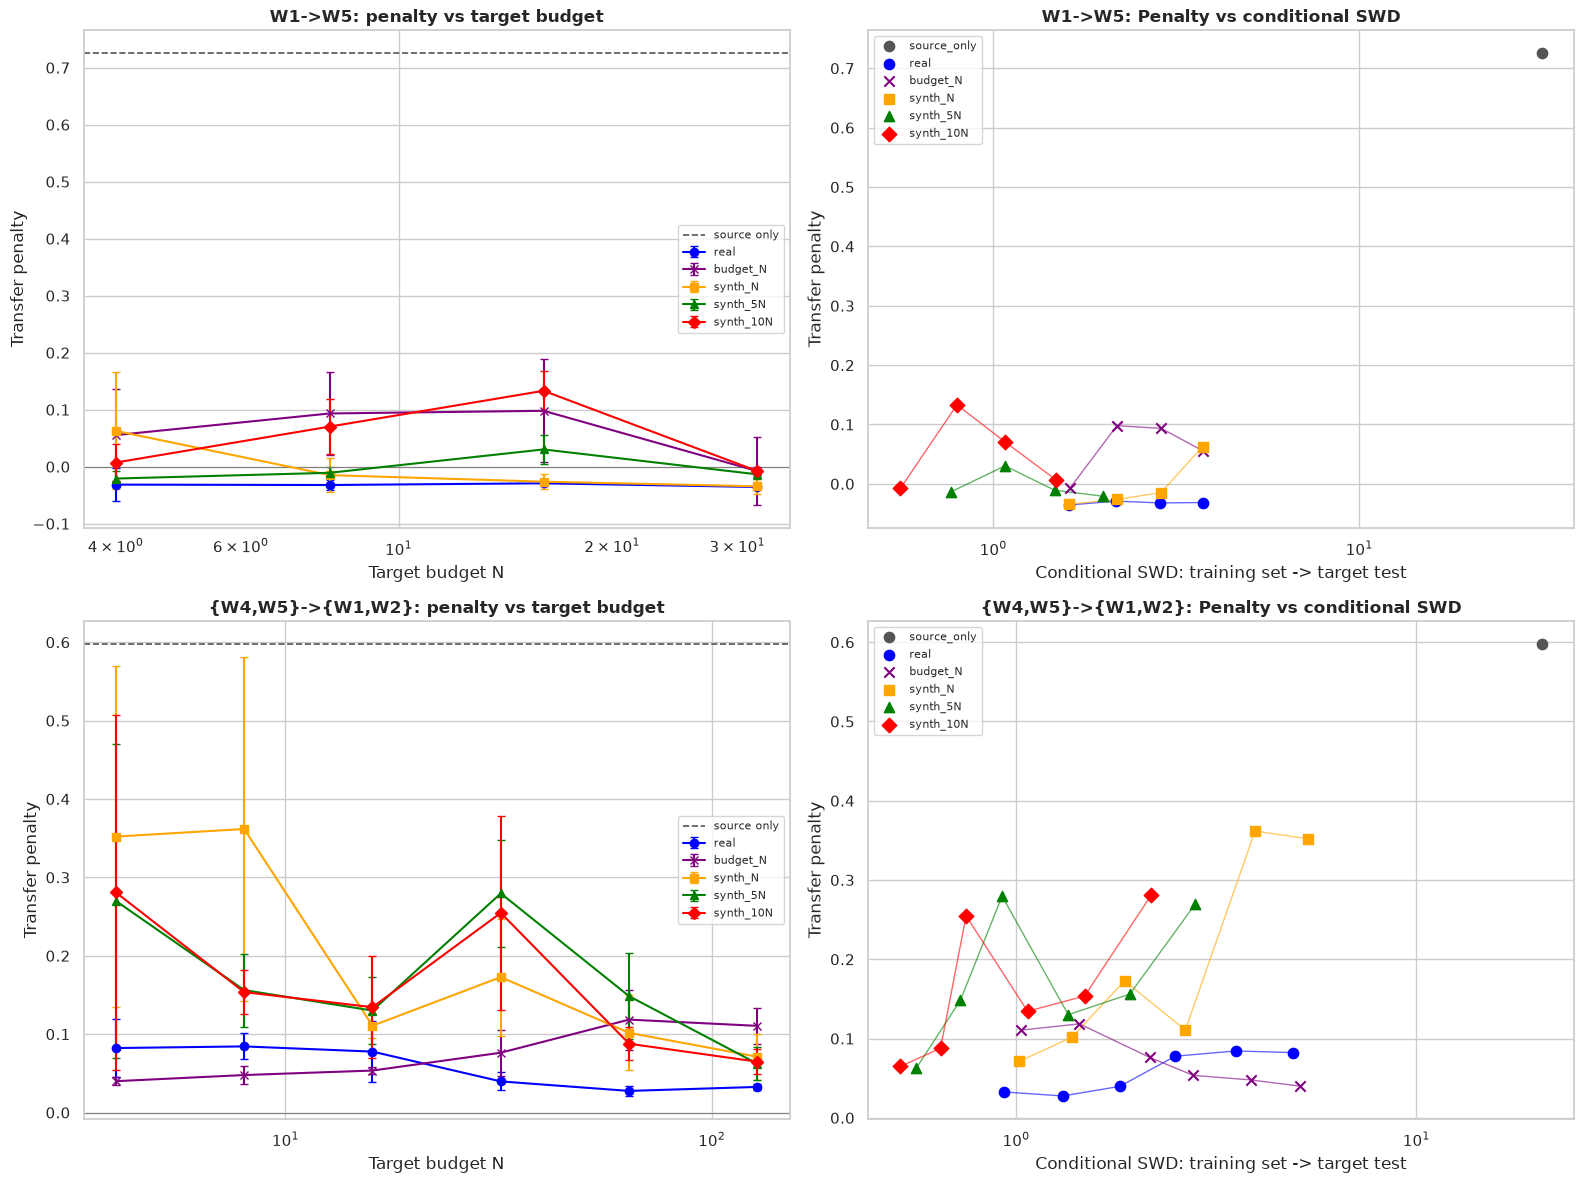

In [18]:
SCEN_STYLE = {
    'source_only': dict(color='#555555', ls='--', marker='o'),
    'real': dict(color='blue', marker='o'),
    'budget_N': dict(color='purple', marker='x'),
    'synth_N': dict(color='orange', marker='s'),
    'synth_5N': dict(color='green', marker='^'),
    'synth_10N': dict(color='red', marker='D'),
}


def plot_pair(name: str, tbl: pd.DataFrame, dist: str, ax_pen: plt.Axes, ax_swd: plt.Axes):
    """
    Penalty-vs-N and distance-vs-penalty panels for one pair.
    Args:
        name (str): Name of the source-target pair
        tbl (pd.DataFrame): Aggregated results DataFrame for the pair
        dist (str): Distance metric to plot on the x-axis of the second panel ('SWD', 'MMD', or 'FD')
        ax_pen (plt.Axes): Axes object for the penalty-vs-N panel
        ax_swd (plt.Axes): Axes object for the distance-vs-penalty panel
    """
    src_only = tbl[tbl['N'] == 0].iloc[0]
    sub = tbl[tbl['N'] > 0].copy()
    sub['N'] = sub['N'].astype(int)

    # First plot: penalty vs budget N
    ax_pen.set_xscale('log')
    for scen in SCENARIOS:
        if scen == 'source_only':
            ax_pen.axhline(src_only['penalty_mean'], color='#555555', ls='--', lw=1.2, label='source only')
            continue
        s = sub[sub['scenario'] == scen]
        if s.empty:
            continue
        st = SCEN_STYLE[scen]
        ax_pen.errorbar(s['N'], s['penalty_mean'], yerr=s['penalty_std'], color=st['color'], marker=st['marker'], lw=1.5, capsize=3, label=scen)
    ax_pen.axhline(0, color='gray', lw=0.8)
    ax_pen.set_xlabel('Target budget N')
    ax_pen.set_ylabel('Transfer penalty')
    ax_pen.set_title(f'{name}: penalty vs target budget', fontweight='bold', fontsize=12)
    ax_pen.legend(fontsize=8)

    # Second plot: penalty vs conditional SWD distance to the test set
    pts = [src_only]
    for scen in SCENARIOS[1:]:
        s = sub[sub['scenario'] == scen]
        if s.empty:
            continue
        pts.append(s)
    for s in pts:
        scen = s['scenario'] if isinstance(s, pd.Series) else s['scenario'].iloc[0]
        st = SCEN_STYLE[scen]
        ax_swd.scatter(s[dist], s['penalty_mean'], color=st['color'], marker=st['marker'], s=55, label=scen, zorder=3)
        if scen != 'source_only':
            ax_swd.plot(s[dist], s['penalty_mean'], color=st['color'], lw=1.0, alpha=0.6)
    ax_swd.set_xscale('log')
    ax_swd.set_xlabel(f'Conditional {dist}: training set -> target test')
    ax_swd.set_ylabel('Transfer penalty')
    ax_swd.set_title(f'{name}: Penalty vs conditional {dist}', fontweight='bold', fontsize=12)
    ax_swd.legend(fontsize=8)


fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for i, name in enumerate(PAIRS):
    plot_pair(name, tables[name], 'SWD', axes[i, 0], axes[i, 1])
plt.tight_layout()
plt.show()


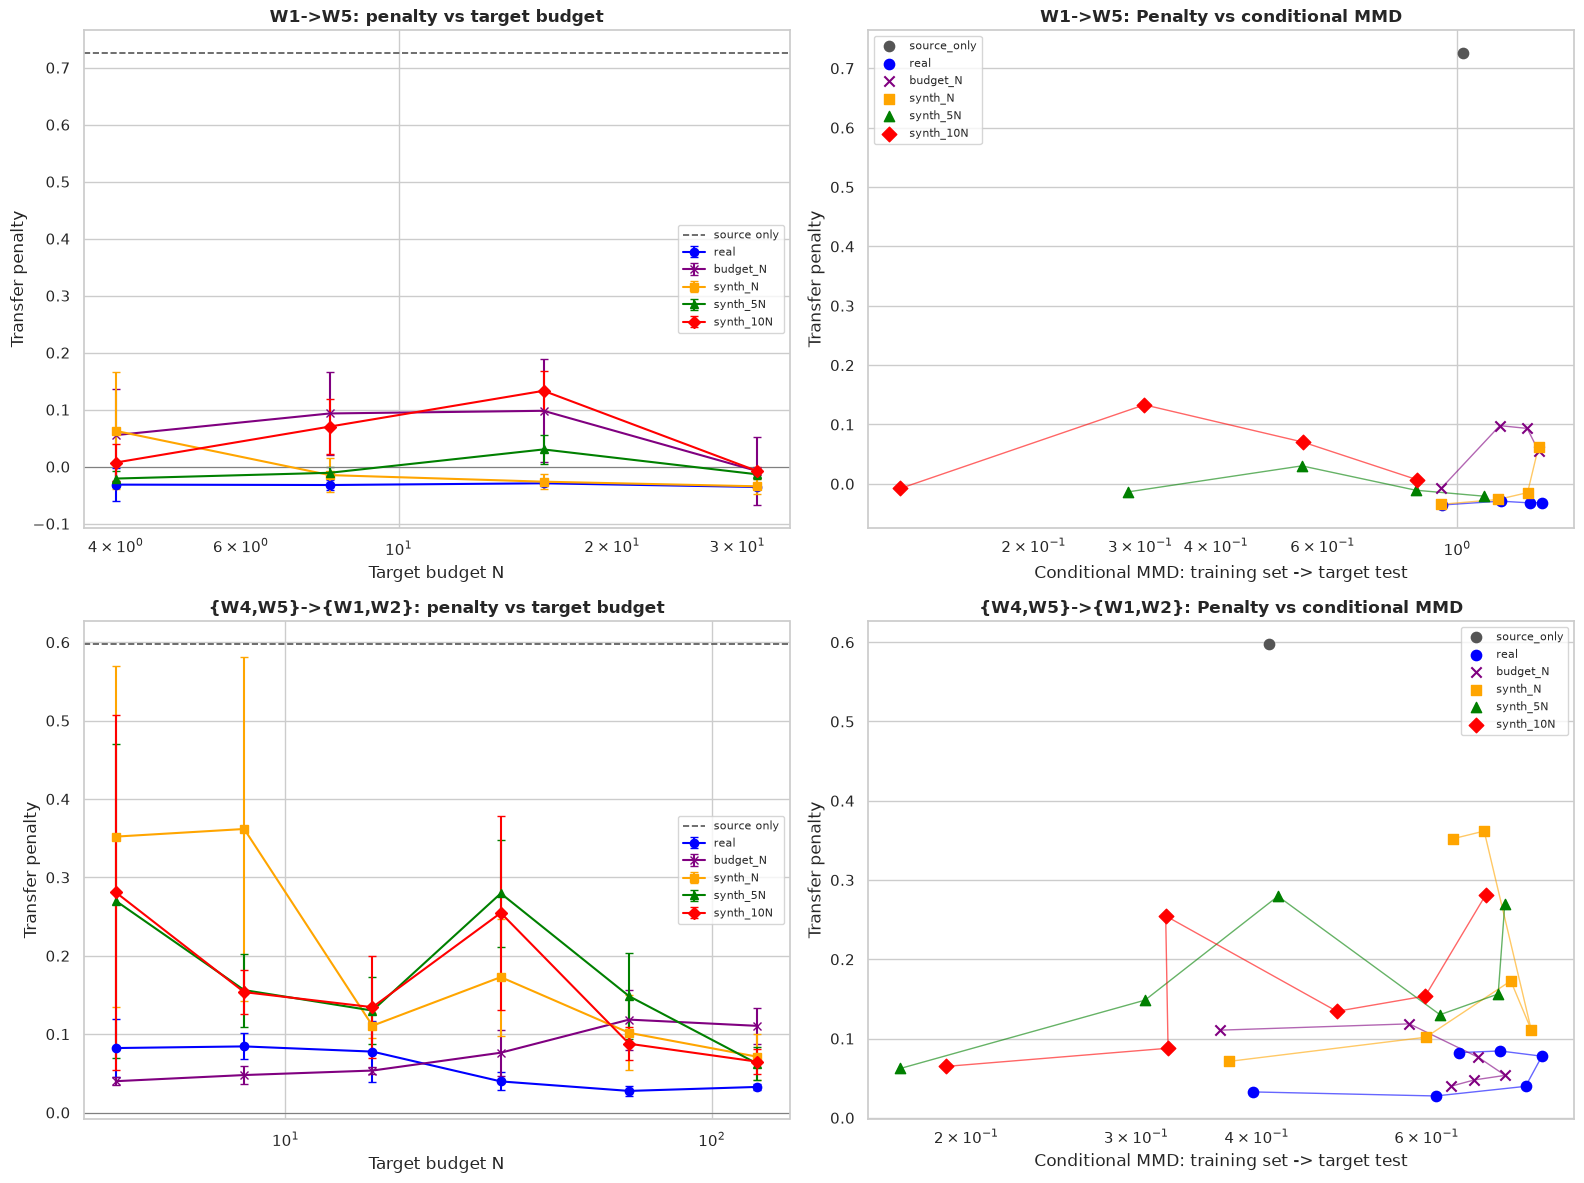

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for i, name in enumerate(PAIRS):
    plot_pair(name, tables[name], 'MMD', axes[i, 0], axes[i, 1])
plt.tight_layout()
plt.show()

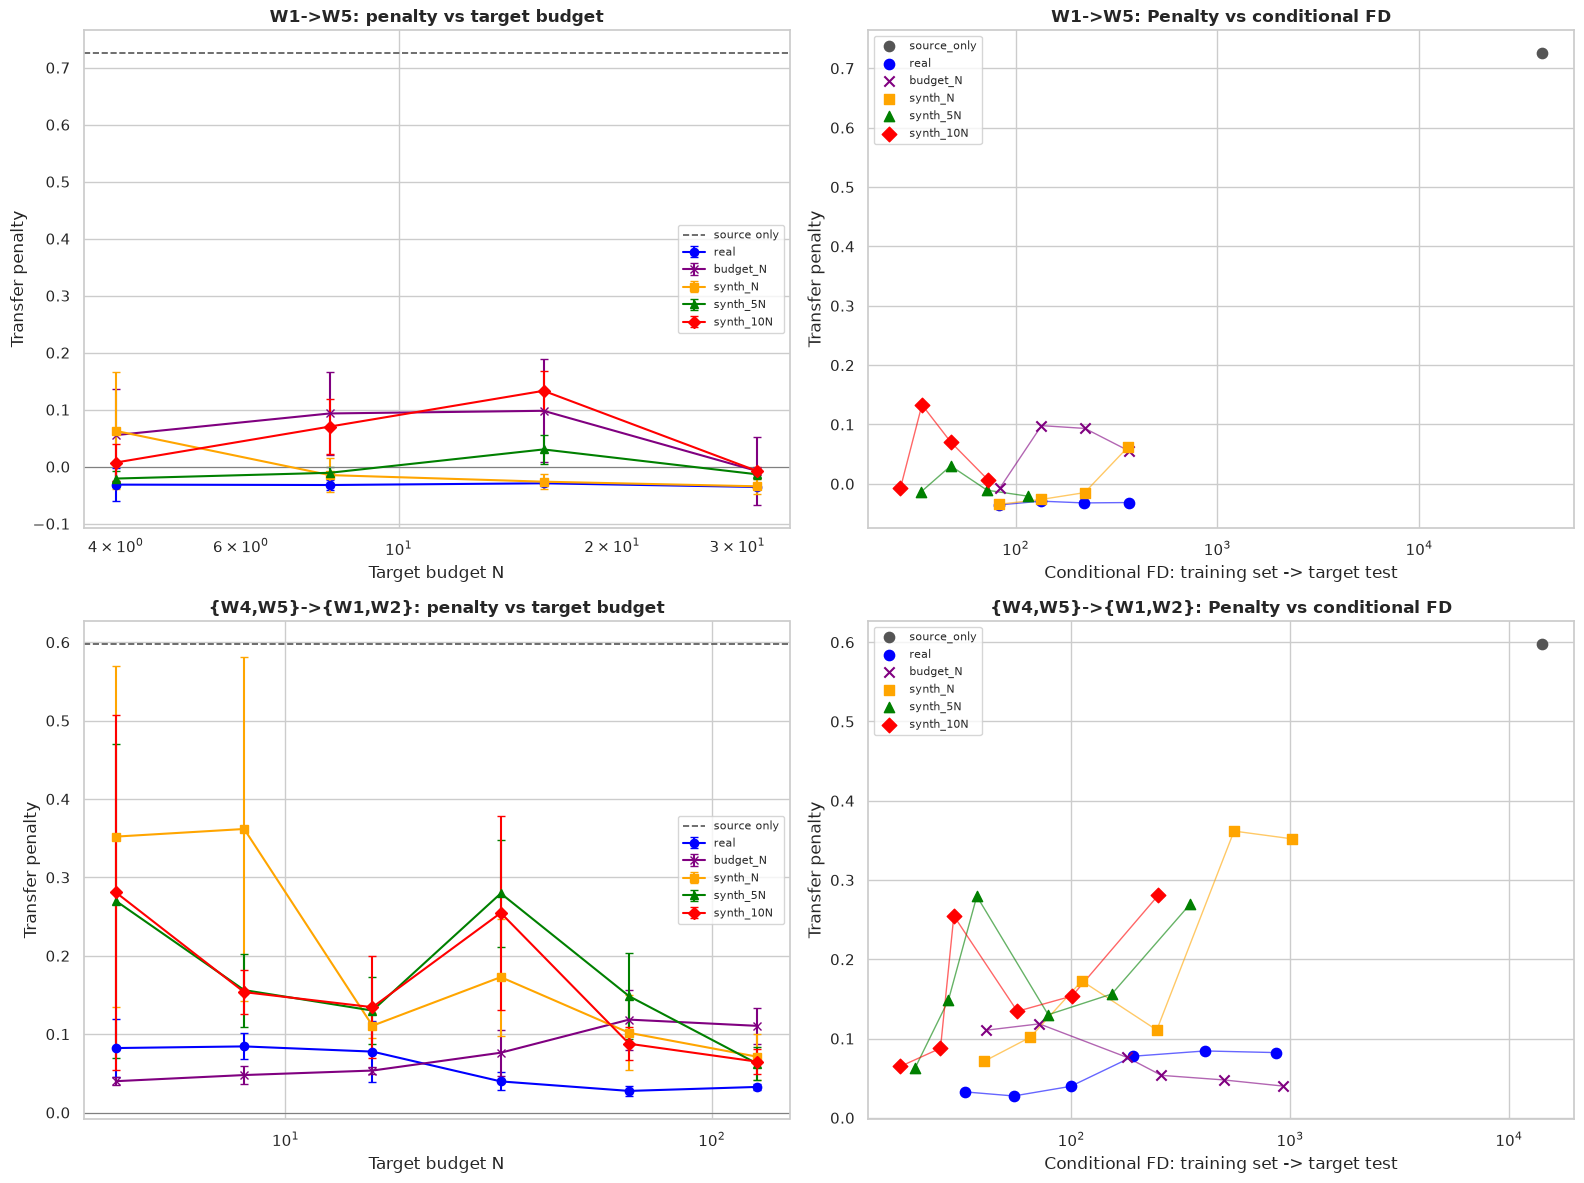

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for i, name in enumerate(PAIRS):
    plot_pair(name, tables[name], 'FD', axes[i, 0], axes[i, 1])
plt.tight_layout()
plt.show()

## Conclusion

Even if the budget on which train the CVAE generator is limited, some trends are clear:

1. **A small labeled target budget is very effective.** Regarding the well-to-well pair, the source-only penalty is 0.726, but adding just 4 real target instances reduces it to -0.031, with similar results with 8, 16 and 32 instances. This shows that synthetic data might not be necessary to obtain a good transfer performance. Similar results are obtained on the well-group pair, where the source-only penalty is 0.598, but adding just 4 real target instances reduces to 0.082, reaching 0.033 with 128 instances.

2. **Synthetic data is not always necessary.** Looking at the penalty curves, we can observe that Random Forests trained with synthetic data always performs worse or equal to the ones trained on a small number of real target instances. This is true for both pairs, and it is more evident on the well-group pair, where the source-pretrained CVAE is not able to generate good synthetic data. In general, as the budget N increases for both CVAE training and Random Forest training, the penalty decreases. This suggests that this could be a scalable approach, but on this dataset because of the scarcity of target data, this cannot be fully proven.

3. **Correlation between penalty and conditional distance.** Observing the penalty vs conditional distance plots, we can see that the penalty decreases as the distance decreases, this is true mostly for the well group pair, where the source-pretrained CVAE is not able to generate good synthetic data when fine-tuned on a small number of target instances, showing also a higher distance to the target test set. As observed in stage 2, also here we confirm that MMD is not a good distance metric to predict the ability of a training set to transfer to the target domain, while SWD and FD visually show a better correlation with the penalty.